# Colormaps

A palette is named wherever a theme asks for colors: the two general palettes, the heatmap colormap, and the parallel-coordinates hues. The name is resolved through [pypalettes](https://y-sunflower.github.io/pypalettes/), which gives access to over 2500 palettes; the [COLORS](../../../references/constants/#datachart.constants.COLORS) constant is a curated selection of them, rendered on this page. Which kind of palette a role wants:

| Role                                       | Attribute                                            | Kind                     |
| :----------------------------------------- | :--------------------------------------------------- | :----------------------- |
| Series sharing one axes                    | `color_general_multiple`                             | Categorical              |
| Single-color roles (network nodes, parallel ramp) | `color_general_singular`             | Sequential               |
| Heatmap cells                              | `plot_heatmap_cmap`                                  | Sequential               |
| Heatmap cells under a centred norm         | `plot_heatmap_cmap_diverging`                        | Diverging                |
| Parallel-coordinates hue                   | `color_parallel_hue`, `color_parallel_hue_continuous` | Categorical, sequential |

A palette asked for one color gives its last one, so a sequential palette yields one strong color and a graded set when several are asked for. The calendar heatmap, hexbin, and contour colormaps follow the heatmap's unless set. A heatmap drawn with `norm="centered"` or `norm="twoslope"` takes `plot_heatmap_cmap_diverging` in place of `plot_heatmap_cmap`, so a signed matrix reads its sign as a hue; see the [Heatmap guide](../../charts/heatmap/#normalization). See the [Themes](../themes/) guide for setting these attributes and building a theme around them.

Each palette below is shown as a continuous strip and as the six colors a chart with six series receives; hover a swatch for its hex code. A palette is passed as its `COLORS` value, or as the plain name string.


In [1]:
from datachart.constants import COLORS


In [2]:
from IPython.display import HTML, display
from matplotlib.colors import to_hex

from datachart.utils._internal.colors import get_colormap, get_discrete_colors

CONSTANT = {
    value: f"COLORS.{name}"
    for name, value in vars(COLORS).items()
    if isinstance(value, str) and not name.startswith("_")
}

SHOWN = set()

CSS = """
<style>
.palettes { display: flex; flex-direction: column; gap: .55em; margin: .4em 0 1em; }
.palette { display: grid; grid-template-columns: 11em 1fr; gap: .25em 1em; align-items: start; min-height: 2.3em; }
.palette .name { display: flex; flex-direction: column; }
.palette .name code { display: flex; align-items: center; height: 1.75em; font-size: .8em; background: none; padding: 0; }
.palette .name small { opacity: .6; font-size: .64em; line-height: 1.2; }
.palette .strips { display: flex; align-items: center; gap: .8em; flex-wrap: wrap; }
.palette .strip { flex: 1 1 14em; height: 1.4em; border-radius: .3em; box-shadow: inset 0 0 0 1px rgba(0,0,0,.12); }
.palette .steps { display: flex; gap: .25em; }
.palette .steps span { width: 1.4em; height: 1.4em; border-radius: .25em; box-shadow: inset 0 0 0 1px rgba(0,0,0,.12); }
@media screen and (max-width: 44.984375em) {
  .palette { grid-template-columns: 1fr; }
}
</style>
"""


def _label(palette):
    if isinstance(palette, list):
        return "<code>[...]</code><small>list of colors</small>"
    constant = CONSTANT.get(palette)
    if constant is None:
        return f'<code>"{palette}"</code>'
    note = f"<small>{palette}</small>" if palette != constant.split(".")[1] else ""
    return f"<code>{constant}</code>{note}"


def _row(palette):
    cmap = get_colormap(palette)
    stops = ", ".join(to_hex(cmap(i / 23)) for i in range(24))
    steps = "".join(
        f'<span style="background:{c}" title="{c}"></span>'
        for c in get_discrete_colors(palette, 6)
    )
    return (
        f'<div class="palette"><div class="name">{_label(palette)}</div>'
        f'<div class="strips"><div class="strip" style="background: linear-gradient(90deg, {stops})"></div>'
        f'<div class="steps">{steps}</div></div></div>'
    )


def palettes(*names):
    SHOWN.update(n for n in names if isinstance(n, str))
    rows = "".join(_row(n) for n in names)
    display(HTML(f'{CSS}<div class="palettes">{rows}</div>'))


## Sequential, Single Hue

One hue from light to dark, ordered by magnitude. The natural `color_general_singular` palette: a role that needs one color takes the dark end. Also the safest heatmap colormap.


In [3]:
palettes(
    COLORS.Blues,
    COLORS.Greens,
    COLORS.Oranges,
    COLORS.Purples,
    COLORS.Reds,
)


## Sequential, Multiple Hues

Light to dark through two or more hues, which separates neighbouring values better than a single hue. Suited to heatmaps and value scales; the last color still serves a single series.


In [4]:
palettes(
    COLORS.YlGnBu,
    COLORS.YlOrRd,
    COLORS.YlOrBr,
    COLORS.PuBuGn,
    COLORS.GnBu,
    COLORS.BuPu,
    COLORS.PuBu,
    COLORS.Sunset2,
    COLORS.Egypt,
    COLORS.Hiroshige,
    COLORS.Lake,
    COLORS.Neon,
)


## Diverging

Two hues meeting at a neutral center, for values with a meaningful midpoint: differences from a baseline, correlations, gains and losses. Use with a heatmap `norm` centred on that value.


In [5]:
palettes(
    COLORS.RdBu,
    COLORS.BrBG,
    COLORS.PuOr,
    COLORS.Spectral,
    COLORS.RdYlBu,
    COLORS.RdYlGn,
    COLORS.Coolwarm,
)


## Categorical

Distinct hues of similar weight, for series that are different in kind rather than in amount: the `color_general_multiple` palette. The six colors shown are the ones six series receive.


In [6]:
palettes(
    COLORS.Set1,
    COLORS.Set2,
    COLORS.Dark2,
    COLORS.Accent,
    COLORS.Paired,
    COLORS.Pastel,
    COLORS.Tab10,
    COLORS.Tab20,
)


## Perceptually Uniform and Color-Blind Safe

Equal steps in value read as equal steps in color, and the palettes stay distinguishable under the common forms of color-vision deficiency. The first six are sequential, the Okabe-Ito pair categorical.


In [7]:
palettes(
    COLORS.Viridis,
    COLORS.Cividis,
    COLORS.Inferno,
    COLORS.Plasma,
    COLORS.Magma,
    COLORS.Turbo,
    COLORS.OkabeIto,
    COLORS.OkabeIto_Black,
)


## Greyscale

For print and black-and-white reproduction; the greyscale themes pair it with hatching or markers to keep series apart.


In [8]:
palettes(COLORS.Greys)


## Datachart's Own

Palettes registered by datachart rather than pypalettes: the two publication palettes of the ink theme, and the tuned categorical leads of the derived themes (harbor, muted, contrast, hatch and slate-hatch), each stepped so every pair of series stays apart for colour-blind readers. They cycle through their exact colors instead of interpolating, so the series colors are always the ones listed.


In [9]:
palettes(
    COLORS.PaperYlGnBu,
    COLORS.PaperAccent,
    COLORS.Harbor,
    COLORS.TolMuted,
    COLORS.Contrast,
    COLORS.Rust,
    COLORS.Slate,
)


In [10]:
assert SHOWN == set(CONSTANT), sorted(set(CONSTANT) ^ SHOWN)


## Beyond the Constant

Any pypalettes name works where a `COLORS` value does. So does a single matplotlib color, which is a palette of one and repeats for every series, and a list of hex colors, which cycles through its exact colors like datachart's own palettes. The list is how the predefined themes define most of their series palettes, and how a custom theme states its own:


In [11]:
palettes("Antique", "#B5651D", ["#0B3954", "#FF6663", "#E0FF4F"])


## Using a Palette in a Theme

A palette is set through the attributes in the table above, here for one figure with `override`; a theme sets the same attributes once. The heatmap takes its own colormap, the bars the general series palette:


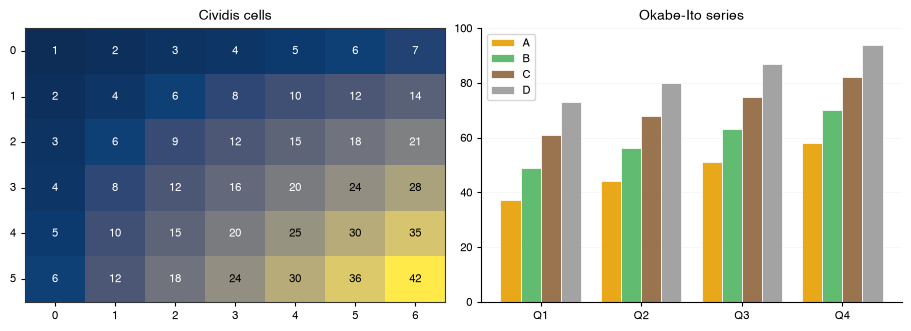

In [12]:
from datachart.charts import BarChart, Heatmap
from datachart.config import config
from datachart.utils import Grid

CELLS = {"z": [[r * c for c in range(1, 8)] for r in range(1, 7)]}
BARS = [[{"label": f"Q{q}", "y": 30 + 12 * s + 7 * q} for q in range(1, 5)] for s in range(4)]

with config.override(plot_heatmap_cmap=COLORS.Cividis, color_general_multiple=COLORS.OkabeIto):
    Grid(
        [[
            Heatmap(data=CELLS, title="Cividis cells", show_values=True),
            BarChart(data=BARS, title="Okabe-Ito series", subtitle=["A", "B", "C", "D"], show_legend=True),
        ]],
        figsize=(9, 3.2),
    ).show()
